# Palmer Penguins Statistical Analysis
This notebook contains a comprehensive statistical analysis of the Palmer Penguins dataset using R.

In [1]:
# 1. Setup and Package Installation
if(!require(palmerpenguins)) install.packages("palmerpenguins")
if(!require(dplyr)) install.packages("dplyr")
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(e1071)) install.packages("e1071")
if(!require(effsize)) install.packages("effsize")
if(!require(car)) install.packages("car")

library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(e1071)
library(effsize)
library(car)

# Load data and omit NAs
data("penguins")
df <- na.omit(penguins)

Loading required package: palmerpenguins

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘palmerpenguins’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: e1071

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘e1071’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Loading required package: effsize

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package c

## Task 1: Descriptive Statistical Analysis

In [2]:
calc_stats <- function(x) {
  c(
    Mean = mean(x),
    Median = median(x),
    Min = min(x),
    Max = max(x),
    Var = var(x),
    SD = sd(x),
    Q1 = quantile(x, 0.25),
    Q3 = quantile(x, 0.75),
    IQR = IQR(x),
    Skewness = skewness(x),
    Kurtosis = kurtosis(x)
  )
}

# Overall descriptive statistics for body mass
overall_stats <- calc_stats(df$body_mass_g)
print("Overall Statistics for Body Mass:")
print(overall_stats)

# Species-wise descriptive statistics
species_stats <- df %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Var = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )
print("Species-wise Statistics for Body Mass:")
print(species_stats)

[1] "Overall Statistics for Body Mass:"
         Mean        Median           Min           Max           Var 
 4.207057e+03  4.050000e+03  2.700000e+03  6.300000e+03  6.483725e+05 
           SD        Q1.25%        Q3.75%           IQR      Skewness 
 8.052158e+02  3.550000e+03  4.775000e+03  1.225000e+03  4.680001e-01 
     Kurtosis 
-7.540362e-01 
[1] "Species-wise Statistics for Body Mass:"
# A tibble: 3 × 12
  species    Mean Median   Min   Max     Var    SD    Q1    Q3   IQR Skewness
  <fct>     <dbl>  <dbl> <int> <int>   <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 Adelie    3706.   3700  2850  4775 210332.  459. 3362.  4000  638.   0.274 
2 Chinstrap 3733.   3700  2700  4800 147713.  384. 3488.  3950  462.   0.237 
3 Gentoo    5092.   5050  3950  6300 251478.  501. 4700   5500  800    0.0444
# ℹ 1 more variable: Kurtosis <dbl>


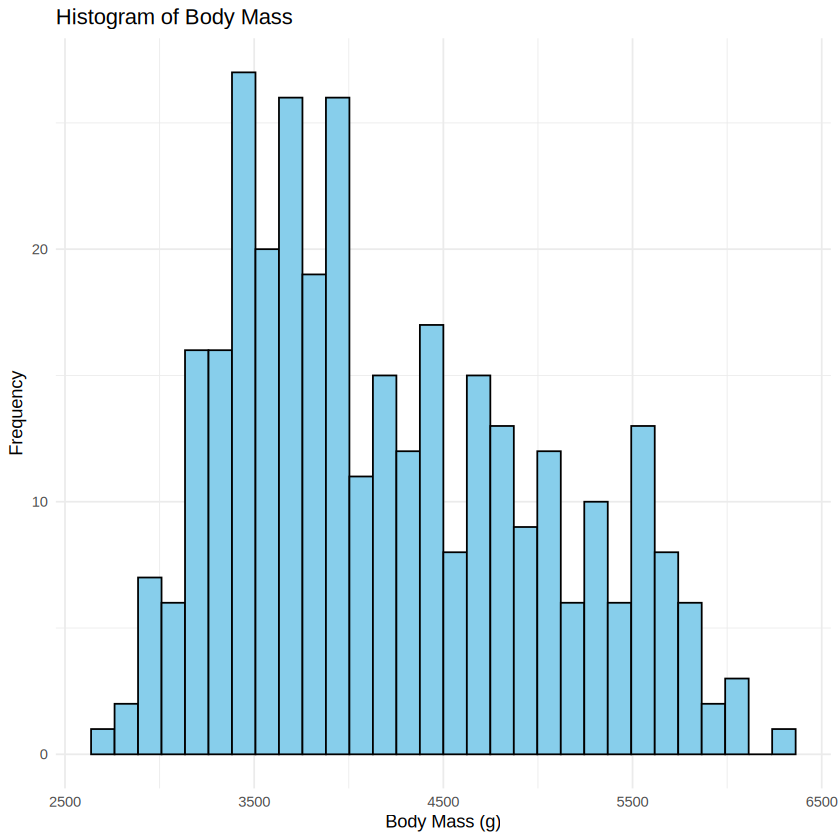

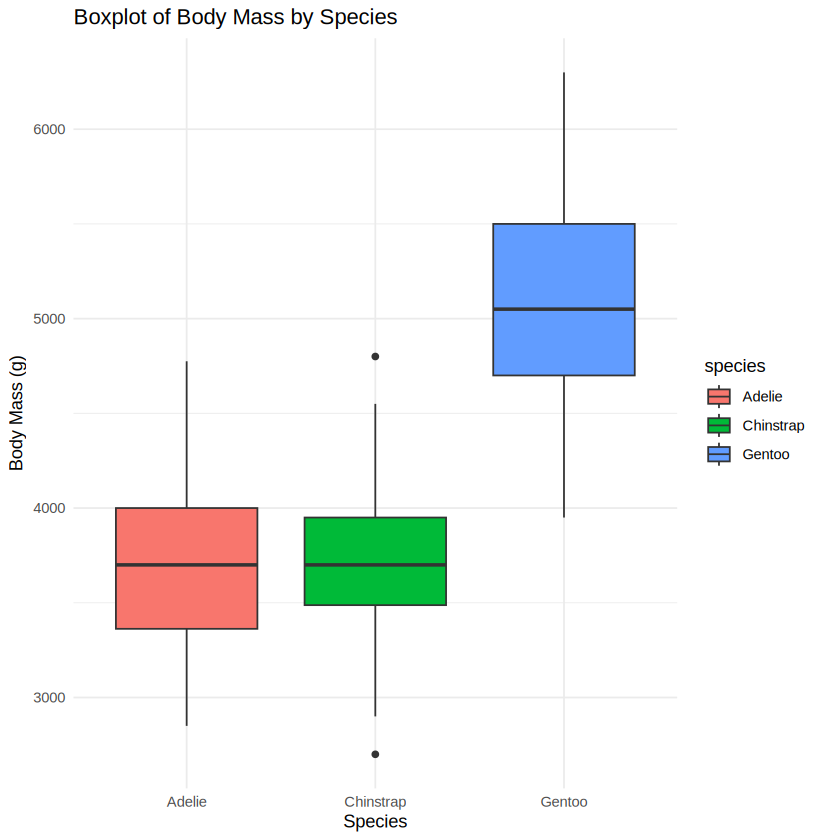

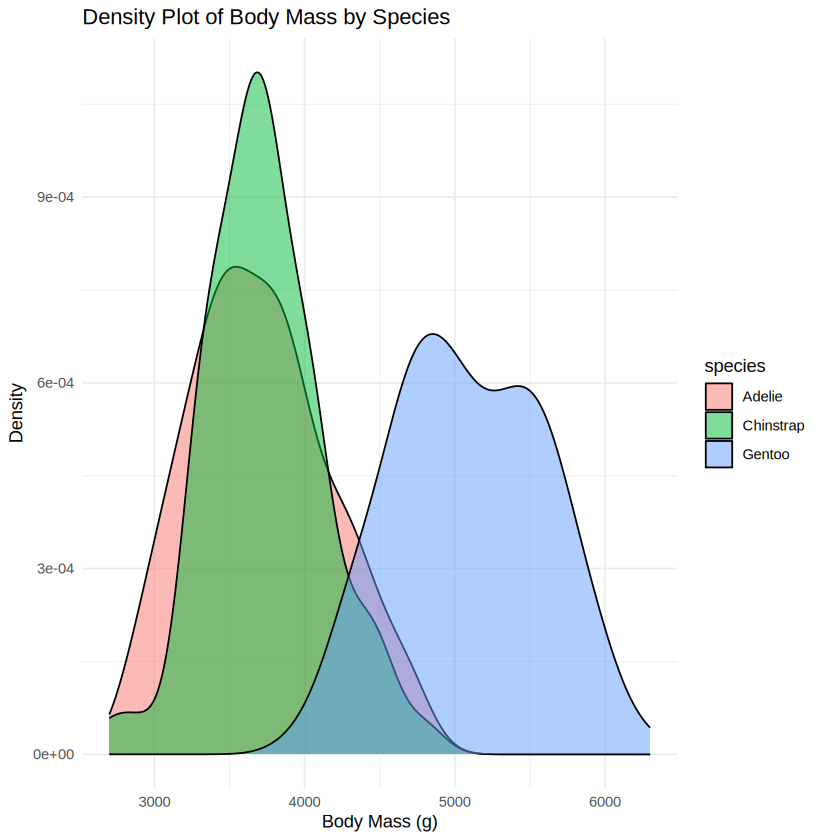

In [3]:
# Visualizations for Task 1
# Histogram
ggplot(df, aes(x = body_mass_g)) +
  geom_histogram(fill = "skyblue", color = "black", bins = 30) +
  theme_minimal() +
  labs(title = "Histogram of Body Mass", x = "Body Mass (g)", y = "Frequency")

# Boxplot
ggplot(df, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Boxplot of Body Mass by Species", x = "Species", y = "Body Mass (g)")

# Density plot
ggplot(df, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density")

## Task 2: Hypothesis Testing (Male vs Female)

[1] "Shapiro-Wilk test (Male):"

	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07

[1] "Shapiro-Wilk test (Female):"

	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08



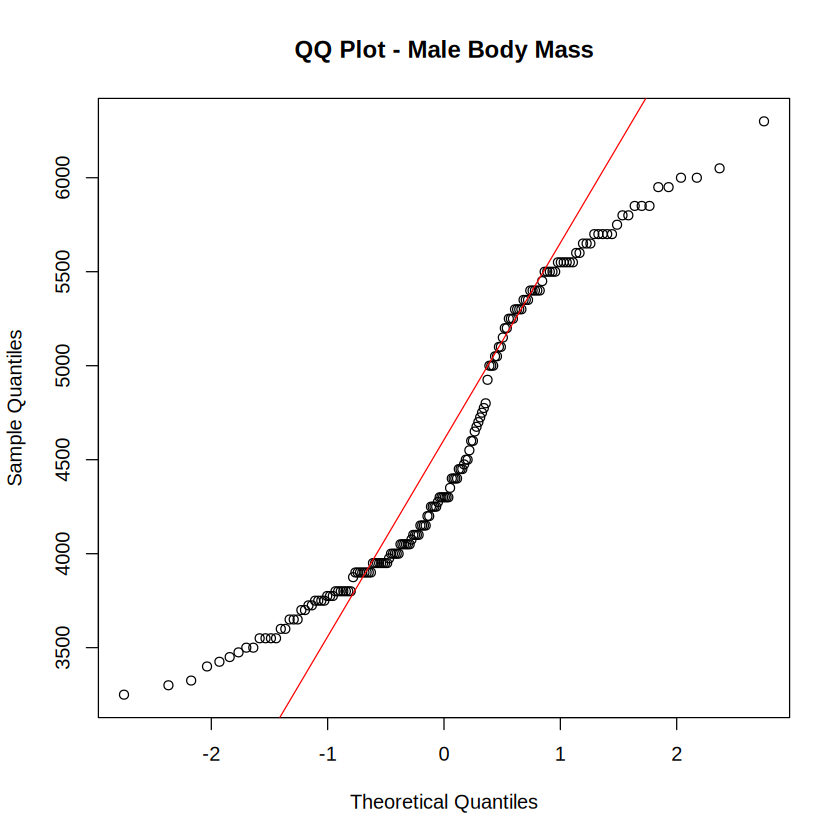

[1] "T-test Result:"

	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 

[1] "Cohen's d:"

Cohen's d

d estimate: -0.9362048 (large)
95 percent confidence interval:
     lower      upper 
-1.1633158 -0.7090938 



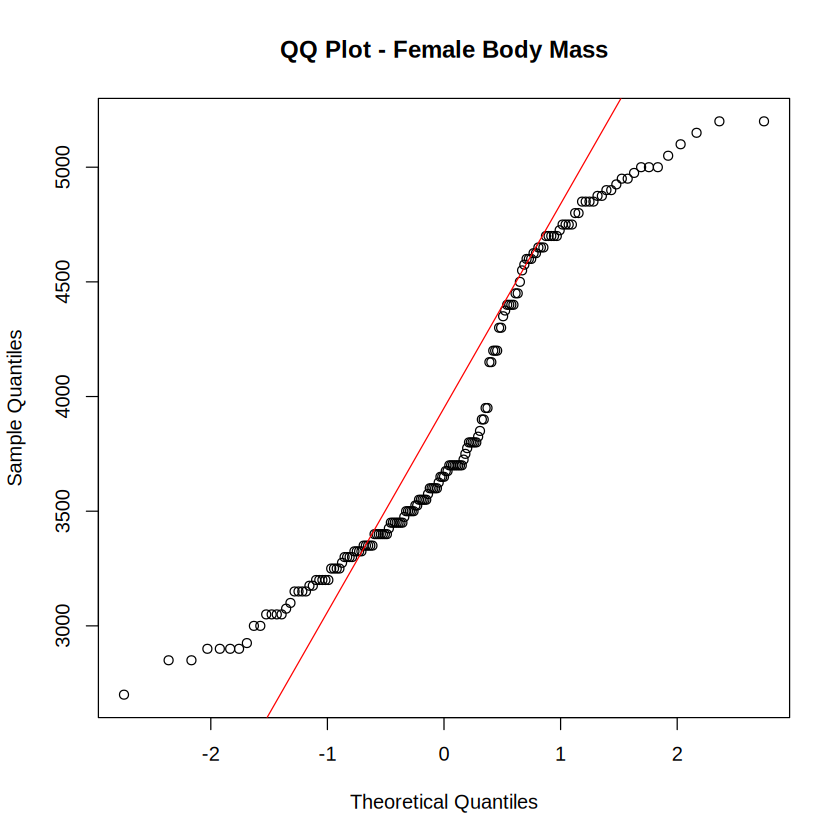

In [4]:
male_mass <- df$body_mass_g[df$sex == "male"]
female_mass <- df$body_mass_g[df$sex == "female"]

# Normality check
shapiro_male <- shapiro.test(male_mass)
shapiro_female <- shapiro.test(female_mass)
print("Shapiro-Wilk test (Male):")
print(shapiro_male)
print("Shapiro-Wilk test (Female):")
print(shapiro_female)

# QQ Plots
qqnorm(male_mass, main = "QQ Plot - Male Body Mass")
qqline(male_mass, col = "red")

qqnorm(female_mass, main = "QQ Plot - Female Body Mass")
qqline(female_mass, col = "red")

# Independent Two-Sample t-test
ttest_res <- t.test(body_mass_g ~ sex, data = df)
print("T-test Result:")
print(ttest_res)

# Effect size (Cohen's d)
cohen_d <- cohen.d(body_mass_g ~ sex, data = df)
print("Cohen's d:")
print(cohen_d)

## Task 3: One-Way ANOVA

[1] "Levene's Test:"
Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "One-Way ANOVA Summary:"


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

[1] "Tukey HSD Post-hoc Test:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = df)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



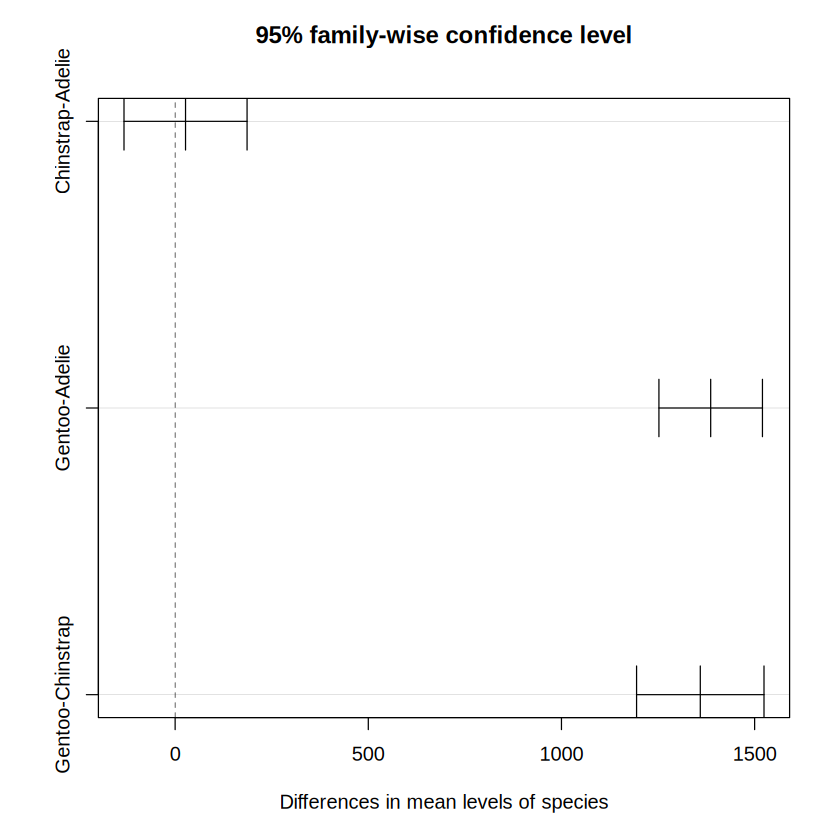

In [5]:
# Check homogeneity of variance
levene_res <- leveneTest(body_mass_g ~ species, data = df)
print("Levene's Test:")
print(levene_res)

# One-way ANOVA
anova_res <- aov(body_mass_g ~ species, data = df)
print("One-Way ANOVA Summary:")
summary(anova_res)

# Tukey HSD Post-hoc
tukey_res <- TukeyHSD(anova_res)
print("Tukey HSD Post-hoc Test:")
print(tukey_res)

# Group Comparison Plot
plot(tukey_res)

## Task 4: Non-Parametric Analysis

In [6]:
kruskal_res <- kruskal.test(body_mass_g ~ species, data = df)
print("Kruskal-Wallis Test:")
print(kruskal_res)

[1] "Kruskal-Wallis Test:"

	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16



## Task 5: Two-Way ANOVA

[1] "Two-Way ANOVA Summary:"


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

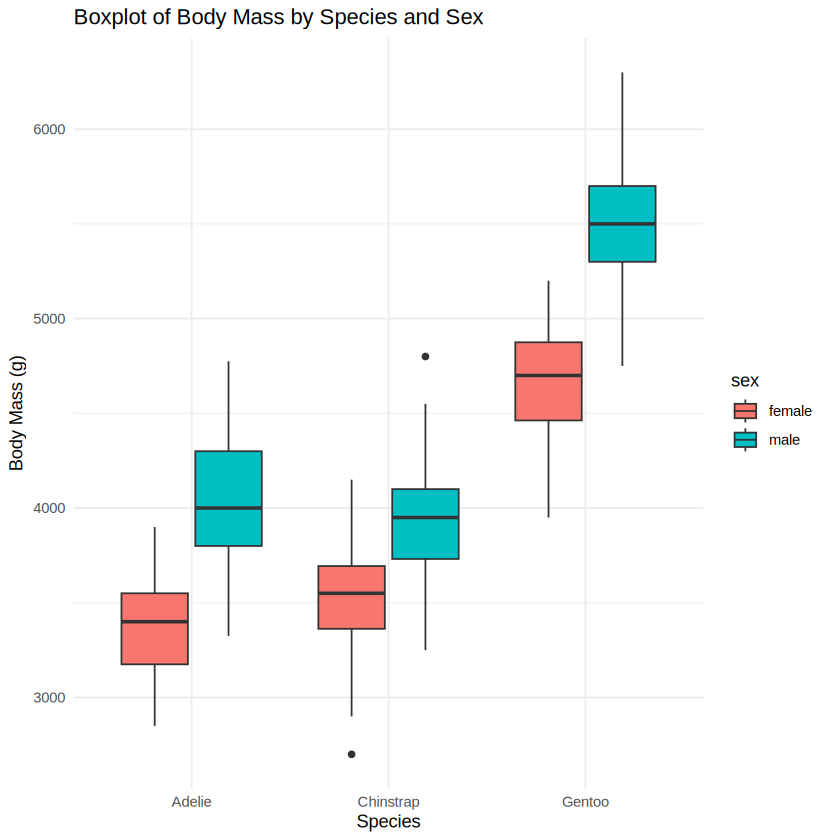

In [7]:
twoway_anova <- aov(body_mass_g ~ species * sex, data = df)
print("Two-Way ANOVA Summary:")
summary(twoway_anova)

# Sex-wise boxplot
ggplot(df, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Boxplot of Body Mass by Species and Sex", x = "Species", y = "Body Mass (g)")

## Task 6: Additional Analysis (Flipper Length)

[1] "One-Way ANOVA (Flipper Length):"


             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

[1] "Tukey HSD (Flipper Length):"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = df)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0



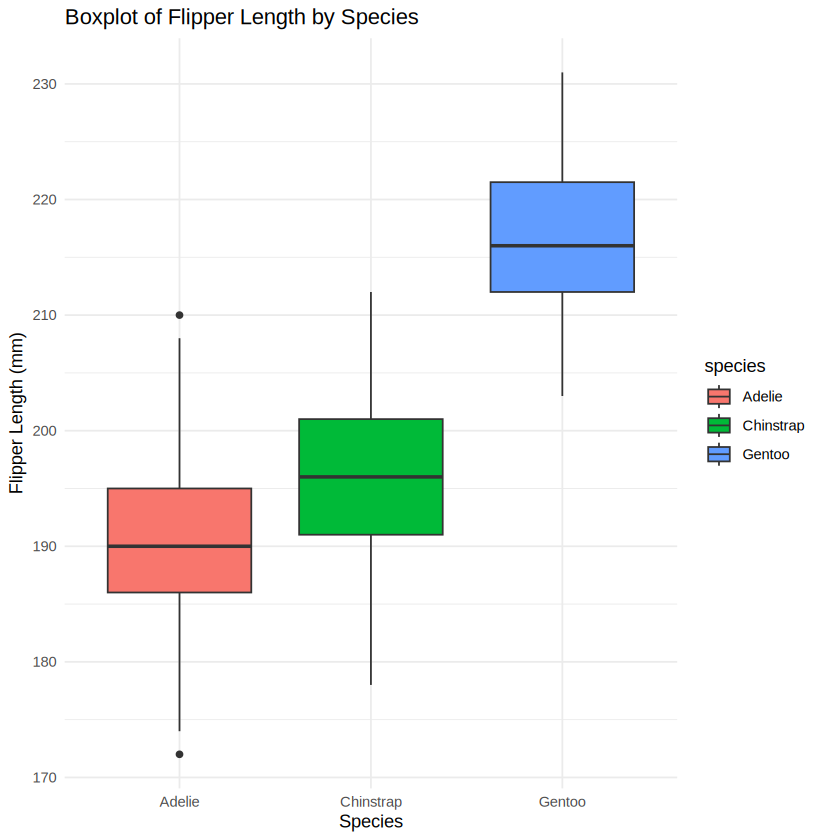

In [8]:
anova_flipper <- aov(flipper_length_mm ~ species, data = df)
print("One-Way ANOVA (Flipper Length):")
summary(anova_flipper)

tukey_flipper <- TukeyHSD(anova_flipper)
print("Tukey HSD (Flipper Length):")
print(tukey_flipper)

# Species-wise flipper-length comparison
ggplot(df, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Boxplot of Flipper Length by Species", x = "Species", y = "Flipper Length (mm)")